# Model Interpretation - XGBoost

This notebook interprets the tuned XGBoost model selected in Notebook 01. It uses training data from November 2025 to June 2026 and validation data from July 2026.


## 1. Setup

Imports, paths, metrics and the fixed XGBoost parameters from Notebook 01.


In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import OneHotEncoder
from xgboost import XGBRegressor


def evaluate_predictions(y_true, y_pred):
    return {
        "MAE": mean_absolute_error(y_true, y_pred),
        "RMSE": np.sqrt(mean_squared_error(y_true, y_pred)),
        "R2": r2_score(y_true, y_pred),
    }


xgboost_params = {
    "n_estimators": 200,
    "max_depth": 2,
    "learning_rate": 0.05,
    "subsample": 0.8,
    "colsample_bytree": 0.8,
    "objective": "reg:squarederror",
    "tree_method": "hist",
    "random_state": 42,
    "n_jobs": -1,
}

pd.set_option("display.max_columns", 60)

PROJECT_DIR = Path.cwd()
while not (PROJECT_DIR / "datasets").exists():
    if PROJECT_DIR == PROJECT_DIR.parent:
        raise FileNotFoundError("Project directory with datasets/ was not found.")
    PROJECT_DIR = PROJECT_DIR.parent

FEATURE_DIR = PROJECT_DIR / "datasets" / "modeling" / "features"
TRAIN_PATH = FEATURE_DIR / "train_features.parquet"
VALIDATION_PATH = FEATURE_DIR / "validation_features.parquet"


## 2. Data

Only the training and July validation feature files are loaded.


In [2]:
train = pd.read_parquet(TRAIN_PATH)
validation = pd.read_parquet(VALIDATION_PATH)

pd.DataFrame(
    [
        {"Dataset": "Training", "Period": "Nov 2025 - Jun 2026", "Rows": len(train)},
        {"Dataset": "Validation", "Period": "Jul 2026", "Rows": len(validation)},
    ]
)


,Dataset,Period,Rows
0,Training,Nov 2025 - Jun 2026,689684
1,Validation,Jul 2026,73867


## 3. Features and preprocessing

The feature set and preprocessing match Notebook 01: categorical values are filled with `missing`, numeric missing values use training-median imputation, and unknown validation categories are ignored by the encoder.


In [3]:
target_column = "delay_target"

categorical_features = [
    "event_hour",
    "event_weekday",
    "rr_precipitation_form",
]

numeric_features = [
    "is_public_holiday",
    "ff_wind_speed_ms",
    "wind_direction_sin",
    "wind_direction_cos",
    "fx_wind_gust_ms",
    "tu_temperature_c",
    "tu_relative_humidity_pct",
    "rr_precipitation_mm",
    "rr_precipitation_indicator",
]

model_features = categorical_features + numeric_features

y_train = train[target_column]
y_validation = validation[target_column]

X_train = train[model_features].copy()
X_validation = validation[model_features].copy()


def prepare_sklearn_features(X):
    X_prepared = X[model_features].copy()
    for column in categorical_features:
        X_prepared[column] = X_prepared[column].fillna("missing").astype(str)
    return X_prepared


X_train_sklearn = prepare_sklearn_features(X_train)
X_validation_sklearn = prepare_sklearn_features(X_validation)

preprocessor = ColumnTransformer(
    transformers=[
        ("numeric", SimpleImputer(strategy="median"), numeric_features),
        ("categorical", OneHotEncoder(handle_unknown="ignore"), categorical_features),
    ]
)

X_train_processed = preprocessor.fit_transform(X_train_sklearn)
X_validation_processed = preprocessor.transform(X_validation_sklearn)

feature_overview = pd.DataFrame(
    {
        "Feature": model_features,
        "Missing Training": [X_train[column].isna().sum() for column in model_features],
        "Missing Validation": [X_validation[column].isna().sum() for column in model_features],
    }
)

feature_overview


,Feature,Missing Training,Missing Validation
0,event_hour,0,0
1,event_weekday,0,0
2,rr_precipitation_form,209,0
3,is_public_holiday,0,0
4,ff_wind_speed_ms,4769,0
5,wind_direction_sin,4205,0
6,wind_direction_cos,4205,0
7,fx_wind_gust_ms,4769,0
8,tu_temperature_c,1506,0
9,tu_relative_humidity_pct,1597,0


## 4. Model reconstruction

The tuned XGBoost model uses the fixed parameters selected in Notebook 01.


In [4]:
xgboost_model = XGBRegressor(**xgboost_params)
xgboost_model.fit(X_train_processed, y_train)

validation_predictions = xgboost_model.predict(X_validation_processed)
validation_metrics = evaluate_predictions(y_validation, validation_predictions)

pd.DataFrame([validation_metrics]).round(6)


,MAE,RMSE,R2
0,6.394587,10.205054,0.01898


## 5. Distribution checks

These checks show missing values, categorical coverage and basic numeric ranges used by the interpretation steps.


In [5]:
categorical_distribution = []
for column in categorical_features:
    categorical_distribution.append(
        {
            "Feature": column,
            "Train categories": X_train_sklearn[column].nunique(dropna=False),
            "Validation categories": X_validation_sklearn[column].nunique(dropna=False),
            "Most common validation value": X_validation_sklearn[column].mode().iloc[0],
        }
    )

numeric_distribution = X_validation[numeric_features].describe(
    percentiles=[0.01, 0.25, 0.5, 0.75, 0.99]
).T[["min", "1%", "25%", "50%", "75%", "99%", "max"]]

print("Categorical coverage")
display(pd.DataFrame(categorical_distribution))
print("Numeric validation distribution")
display(numeric_distribution.round(3))


Categorical coverage


,Feature,Train categories,Validation categories,Most common validation value
0,event_hour,24,24,16
1,event_weekday,7,7,3
2,rr_precipitation_form,6,2,0.0


Numeric validation distribution


,min,1%,25%,50%,75%,99%,max
ff_wind_speed_ms,0.3,0.600,2.000,3.300,4.800,7.6,9.0
wind_direction_sin,-1.0,-1.000,-0.866,-0.342,0.766,1.0,1.0
wind_direction_cos,-1.0,-0.985,-0.342,0.342,0.766,1.0,1.0
fx_wind_gust_ms,0.8,1.600,3.800,6.800,8.900,14.0,20.8
tu_temperature_c,7.7,10.400,18.300,21.800,26.000,34.5,36.4
tu_relative_humidity_pct,20.0,24.000,41.000,54.000,69.000,95.0,96.0
rr_precipitation_mm,0.0,0.000,0.000,0.000,0.000,0.3,4.8
rr_precipitation_indicator,0.0,0.000,0.000,0.000,0.000,1.0,1.0


## 6. Grouped permutation importance

The permutation is applied to original feature groups, not to one-hot encoded dummy columns. Importance is baseline validation R2 minus R2 after permutation.


In [6]:
def predict_xgboost(X):
    return xgboost_model.predict(preprocessor.transform(prepare_sklearn_features(X)))


def grouped_permutation_importance(X, y, groups, repeats=5, random_state=42):
    rng = np.random.default_rng(random_state)
    baseline_r2 = r2_score(y, predict_xgboost(X))
    rows = []

    for group_name, columns in groups.items():
        unique_counts = X[columns].nunique(dropna=False)
        if (unique_counts <= 1).all():
            rows.append(
                {
                    "Feature group": group_name,
                    "Columns": ", ".join(columns),
                    "Baseline R2": baseline_r2,
                    "Mean permuted R2": np.nan,
                    "Importance": np.nan,
                    "Std importance": np.nan,
                    "Status": "constant",
                }
            )
            continue

        importances = []
        permuted_scores = []
        for _ in range(repeats):
            permuted = X.copy()
            order = rng.permutation(len(permuted))
            permuted.loc[:, columns] = X.loc[:, columns].iloc[order].to_numpy()
            permuted_r2 = r2_score(y, predict_xgboost(permuted))
            permuted_scores.append(permuted_r2)
            importances.append(baseline_r2 - permuted_r2)

        rows.append(
            {
                "Feature group": group_name,
                "Columns": ", ".join(columns),
                "Baseline R2": baseline_r2,
                "Mean permuted R2": np.mean(permuted_scores),
                "Importance": np.mean(importances),
                "Std importance": np.std(importances),
                "Status": "ok",
            }
        )

    return pd.DataFrame(rows).sort_values("Importance", ascending=False).reset_index(drop=True)


importance_groups = {
    "Tageszeit": ["event_hour"],
    "Wochentag": ["event_weekday"],
    "Feiertag": ["is_public_holiday"],
    "Temperatur": ["tu_temperature_c"],
    "Relative Luftfeuchtigkeit": ["tu_relative_humidity_pct"],
    "Windgeschwindigkeit": ["ff_wind_speed_ms"],
    "Windrichtung": ["wind_direction_sin", "wind_direction_cos"],
    "Windboeen": ["fx_wind_gust_ms"],
    "Niederschlagsmenge": ["rr_precipitation_mm"],
    "Niederschlagsindikator": ["rr_precipitation_indicator"],
    "Niederschlagsform": ["rr_precipitation_form"],
    "Niederschlag gesamt": [
        "rr_precipitation_mm",
        "rr_precipitation_indicator",
        "rr_precipitation_form",
    ],
}

permutation_importance_results = grouped_permutation_importance(
    X_validation,
    y_validation,
    importance_groups,
    repeats=5,
    random_state=42,
)

permutation_importance_results.round(6)


,Feature group,Columns,Baseline R2,Mean permuted R2,Importance,Std importance,Status
0,Temperatur,tu_temperature_c,0.01898,-0.003712,0.022692,0.000346,ok
1,Wochentag,event_weekday,0.01898,0.004152,0.014828,0.000370,ok
2,Tageszeit,event_hour,0.01898,0.013633,0.005347,0.000308,ok
3,Windboeen,fx_wind_gust_ms,0.01898,0.018735,0.000245,0.000062,ok
4,Windgeschwindigkeit,ff_wind_speed_ms,0.01898,0.018814,0.000166,0.000117,ok
5,Windrichtung,"wind_direction_sin, wind_direction_cos",0.01898,0.018862,0.000117,0.000178,ok
6,Niederschlagsmenge,rr_precipitation_mm,0.01898,0.018982,-0.000002,0.000005,ok
7,Niederschlagsindikator,rr_precipitation_indicator,0.01898,0.019002,-0.000023,0.000006,ok
8,Niederschlagsform,rr_precipitation_form,0.01898,0.019003,-0.000023,0.000002,ok
9,Niederschlag gesamt,"rr_precipitation_mm, rr_precipitation_indicato...",0.01898,0.019039,-0.000060,0.000010,ok


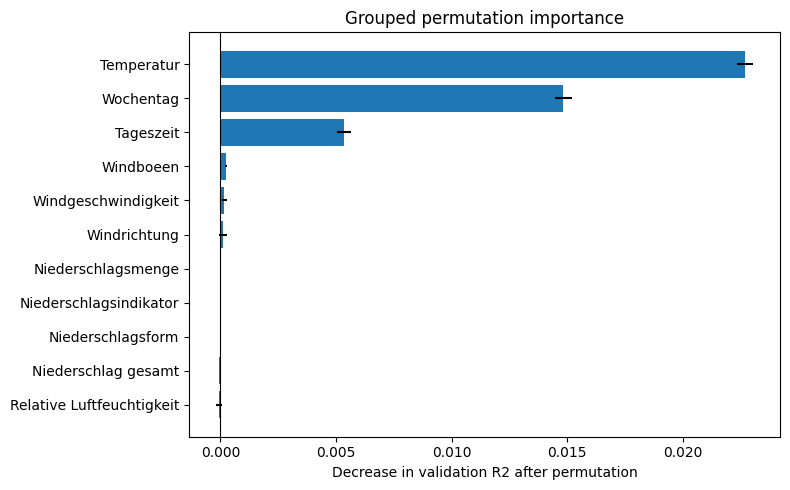

In [7]:
plot_data = permutation_importance_results.dropna(subset=["Importance"]).sort_values("Importance")

fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(plot_data["Feature group"], plot_data["Importance"], xerr=plot_data["Std importance"])
ax.axvline(0, color="black", linewidth=0.8)
ax.set_xlabel("Decrease in validation R2 after permutation")
ax.set_title("Grouped permutation importance")
plt.tight_layout()
plt.show()


## 7. Partial dependence

Partial dependence varies one feature while all other observed validation values stay unchanged. It describes model reactions, not causal effects.


In [8]:
def numeric_grid(series, points=10, include_zero=False):
    values = pd.to_numeric(series, errors="coerce").dropna()
    if include_zero:
        positive = values[values > 0]
        if positive.empty:
            return [0.0]
        grid = np.quantile(positive, np.linspace(0.1, 0.9, points - 1)).tolist()
        return sorted(set([0.0] + [float(value) for value in grid]))
    return sorted(set(float(value) for value in np.quantile(values, np.linspace(0.05, 0.95, points))))


def numeric_partial_dependence(X, feature, values):
    rows = []
    for value in values:
        changed = X.copy()
        changed[feature] = value
        rows.append({"Feature": feature, "Value": value, "Mean prediction": predict_xgboost(changed).mean()})
    return pd.DataFrame(rows)


def categorical_partial_dependence(X, feature, values):
    rows = []
    for value in values:
        changed = X.copy()
        changed[feature] = value
        rows.append({"Feature": feature, "Value": value, "Mean prediction": predict_xgboost(changed).mean()})
    return pd.DataFrame(rows)


pdp_results = {}
pdp_results["event_hour"] = categorical_partial_dependence(
    X_validation,
    "event_hour",
    sorted(X_validation["event_hour"].dropna().unique()),
)
pdp_results["event_weekday"] = categorical_partial_dependence(
    X_validation,
    "event_weekday",
    sorted(X_validation["event_weekday"].dropna().unique()),
)
pdp_results["tu_temperature_c"] = numeric_partial_dependence(
    X_validation,
    "tu_temperature_c",
    numeric_grid(X_validation["tu_temperature_c"]),
)
pdp_results["tu_relative_humidity_pct"] = numeric_partial_dependence(
    X_validation,
    "tu_relative_humidity_pct",
    numeric_grid(X_validation["tu_relative_humidity_pct"]),
)
pdp_results["ff_wind_speed_ms"] = numeric_partial_dependence(
    X_validation,
    "ff_wind_speed_ms",
    numeric_grid(X_validation["ff_wind_speed_ms"]),
)
pdp_results["rr_precipitation_mm"] = numeric_partial_dependence(
    X_validation,
    "rr_precipitation_mm",
    numeric_grid(X_validation["rr_precipitation_mm"], include_zero=True),
)
pdp_results["rr_precipitation_form"] = categorical_partial_dependence(
    X_validation,
    "rr_precipitation_form",
    sorted(X_validation["rr_precipitation_form"].dropna().unique()),
)

pdp_summary = pd.concat(pdp_results.values(), ignore_index=True)
pdp_summary.head(20).round(3)


,Feature,Value,Mean prediction
0,event_hour,0.0,6.150
1,event_hour,1.0,5.917
2,event_hour,2.0,5.822
3,event_hour,3.0,5.092
4,event_hour,4.0,4.509
5,event_hour,5.0,5.495
6,event_hour,6.0,6.284
7,event_hour,7.0,5.926
8,event_hour,8.0,5.881
9,event_hour,9.0,6.074


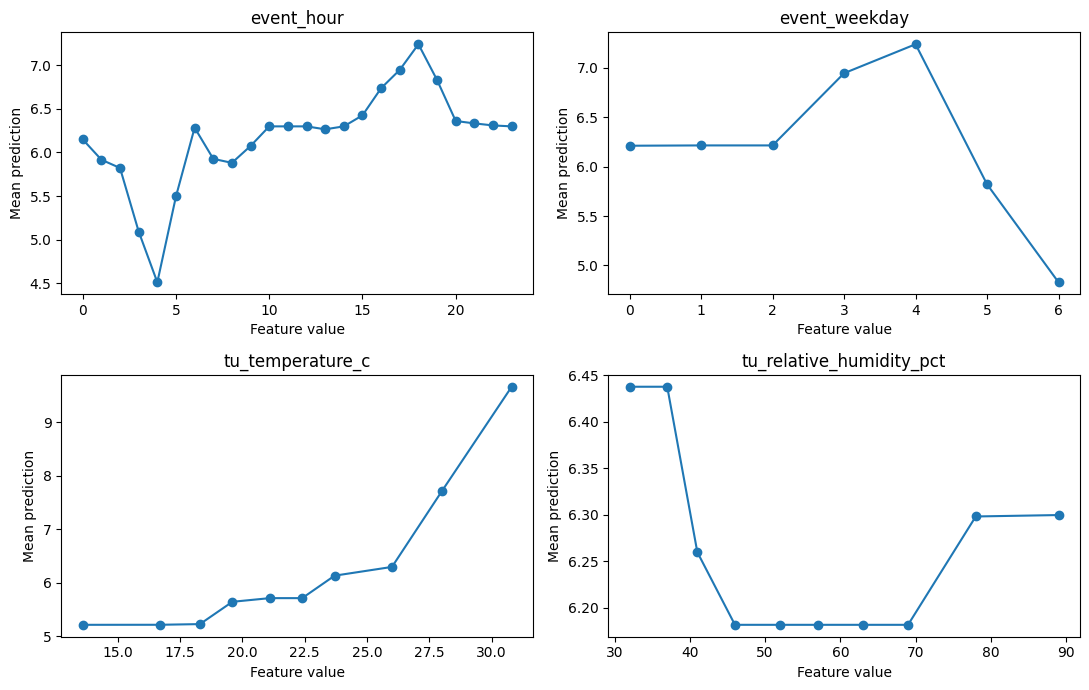

In [9]:
fig, axes = plt.subplots(2, 2, figsize=(11, 7))
axes = axes.ravel()
main_features = ["event_hour", "event_weekday", "tu_temperature_c", "tu_relative_humidity_pct"]

for ax, feature in zip(axes, main_features):
    data = pdp_results[feature]
    ax.plot(data["Value"], data["Mean prediction"], marker="o")
    ax.set_title(feature)
    ax.set_xlabel("Feature value")
    ax.set_ylabel("Mean prediction")

plt.tight_layout()
plt.show()


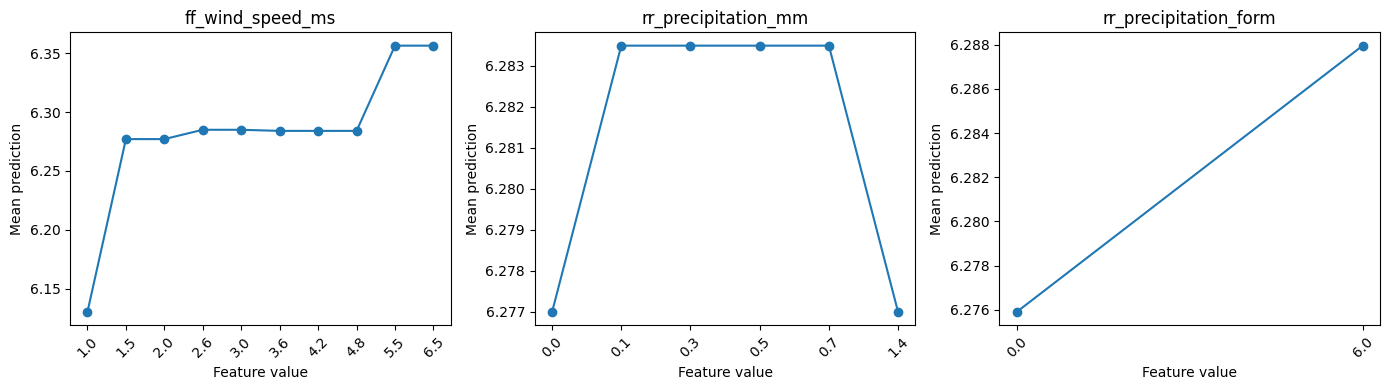

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
extra_features = ["ff_wind_speed_ms", "rr_precipitation_mm", "rr_precipitation_form"]

for ax, feature in zip(axes, extra_features):
    data = pdp_results[feature]
    ax.plot(data["Value"].astype(str), data["Mean prediction"], marker="o")
    ax.set_title(feature)
    ax.set_xlabel("Feature value")
    ax.set_ylabel("Mean prediction")
    ax.tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()


## 8. Short interpretation summary

The tables and plots above describe which original feature groups the fitted model uses most strongly on the July validation set and how predictions change when selected features are varied. The results are descriptive model diagnostics and do not imply causality.


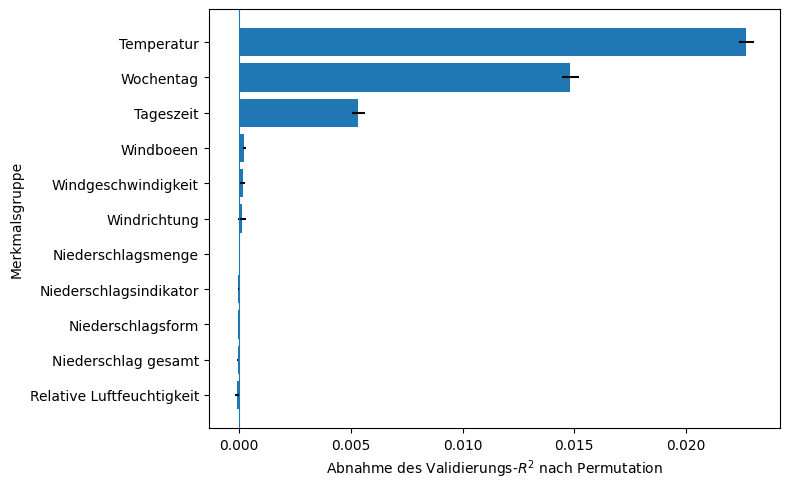

In [11]:
from pathlib import Path
import matplotlib.pyplot as plt

export_dir = PROJECT_DIR / "outputs" / "model_interpretation"
export_dir.mkdir(parents=True, exist_ok=True)

plot_data = (
    permutation_importance_results
    .dropna(subset=["Importance"])
    .sort_values("Importance")
    .copy()
)

plot_data["Feature group"] = plot_data["Feature group"].replace({
    "Time": "Zeitmerkmale",
    "Calendar": "Kalendermerkmale",
    "Temperature": "Temperatur",
    "Humidity": "Relative Luftfeuchtigkeit",
    "Wind": "Wind",
    "Wind direction": "Windrichtung",
    "Wind gusts": "Maximale Windspitze",
    "Precipitation": "Niederschlag"
})

fig, ax = plt.subplots(figsize=(8, 5))

ax.barh(
    plot_data["Feature group"],
    plot_data["Importance"],
    xerr=plot_data["Std importance"]
)

ax.axvline(0, linewidth=0.8)
ax.set_xlabel(r"Abnahme des Validierungs-$R^2$ nach Permutation")
ax.set_ylabel("Merkmalsgruppe")

fig.tight_layout()

fig.savefig(
    export_dir / "permutation_importance_juli.pdf",
    bbox_inches="tight"
)
fig.savefig(
    export_dir / "permutation_importance_juli.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

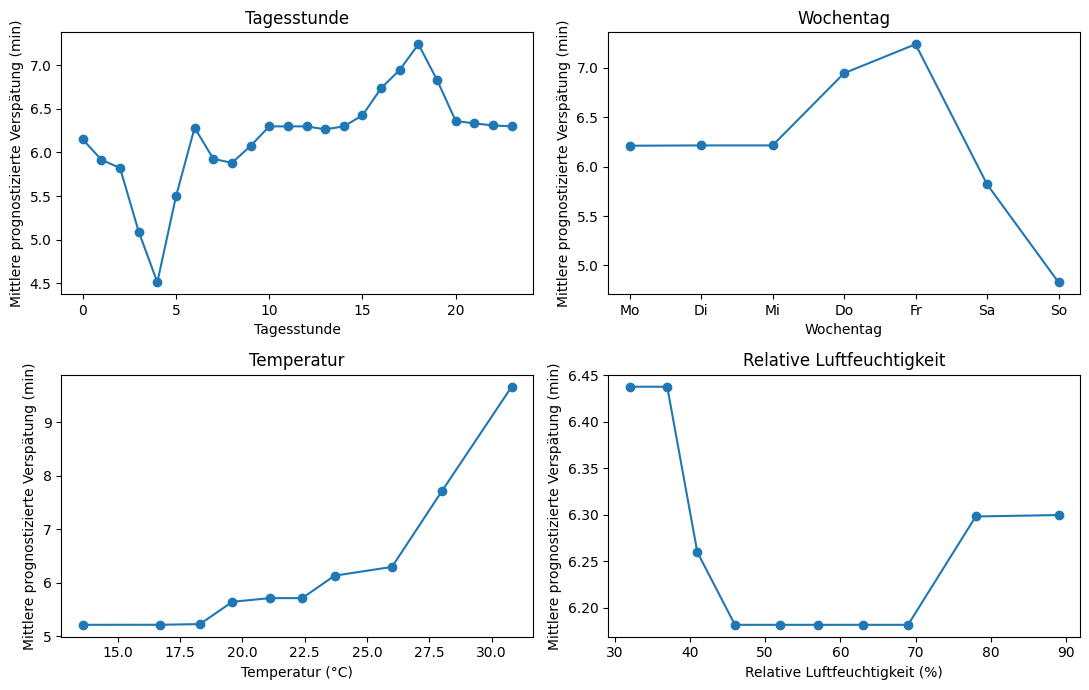

In [12]:
fig, axes = plt.subplots(2, 2, figsize=(11, 7))
axes = axes.ravel()

features = [
    "event_hour",
    "event_weekday",
    "tu_temperature_c",
    "tu_relative_humidity_pct",
]

titles = [
    "Tagesstunde",
    "Wochentag",
    "Temperatur",
    "Relative Luftfeuchtigkeit",
]

xlabels = [
    "Tagesstunde",
    "Wochentag",
    "Temperatur (°C)",
    "Relative Luftfeuchtigkeit (%)",
]

for ax, feature, title, xlabel in zip(axes, features, titles, xlabels):
    data = pdp_results[feature]

    ax.plot(
        data["Value"],
        data["Mean prediction"],
        marker="o"
    )

    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel("Mittlere prognostizierte Verspätung (min)")

weekday_ax = axes[1]
weekday_ax.set_xticks(range(7))
weekday_ax.set_xticklabels(["Mo", "Di", "Mi", "Do", "Fr", "Sa", "So"])

fig.tight_layout()

fig.savefig(
    export_dir / "pdp_xgboost_juli.pdf",
    bbox_inches="tight"
)
fig.savefig(
    export_dir / "pdp_xgboost_juli.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()